<a href="https://colab.research.google.com/github/datweb07/prophet_model/blob/main/prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Vui lòng chọn file MOCK DATA MONTHLY (Có cột Nam, Thang, Tinh...)


Saving MOCK_DATA_MONTHLY_2000_2023.csv to MOCK_DATA_MONTHLY_2000_2023 (1).csv
 Đã load file. Đang xử lý dự báo THEO THÁNG (2026-2028)...

 Đang vẽ biểu đồ mẫu cho trạm: Châu Đốc (Tỉnh An Giang)


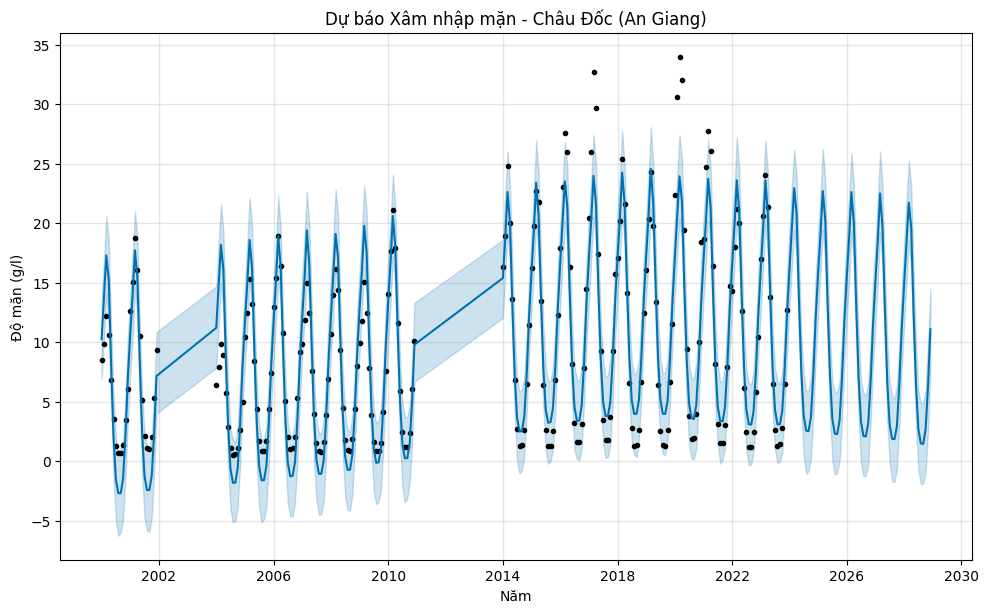


 Đang vẽ biểu đồ mẫu cho trạm: Tân Châu (Tỉnh An Giang)


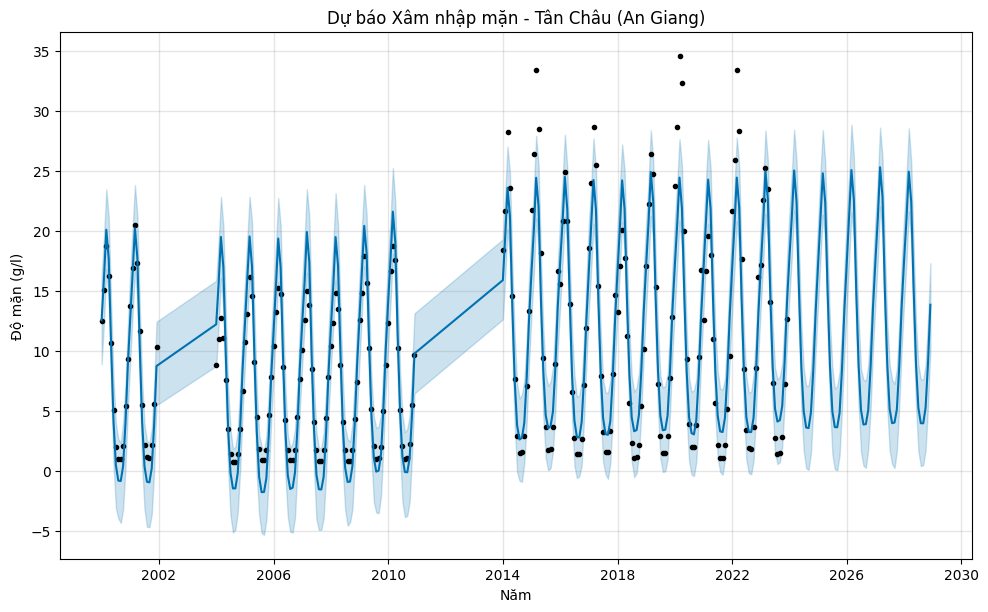


 Đang vẽ biểu đồ mẫu cho trạm: Vàm Nao (Tỉnh An Giang)


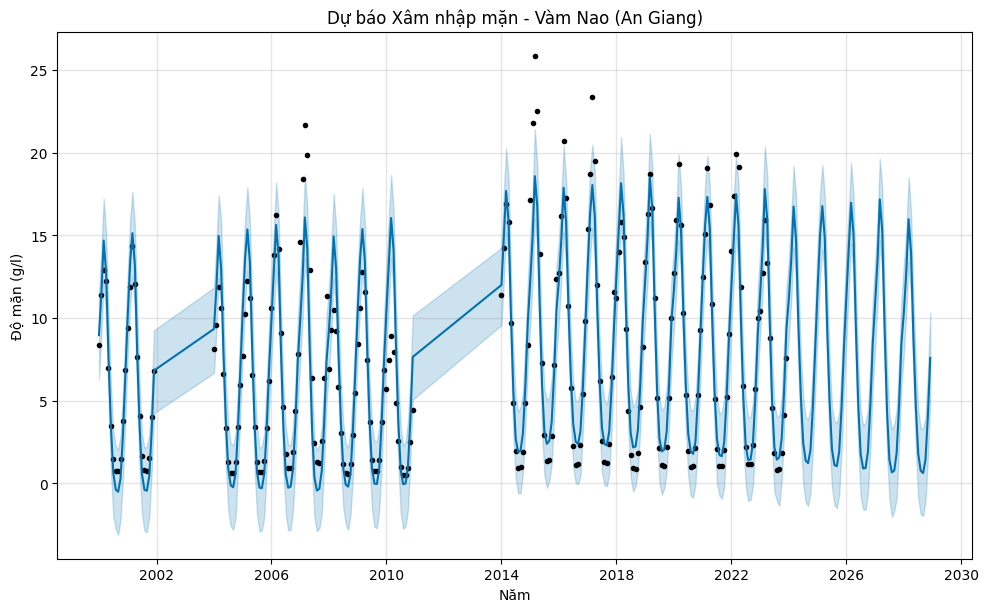


 Đang vẽ biểu đồ mẫu cho trạm: Xuân Tô (Tỉnh An Giang)


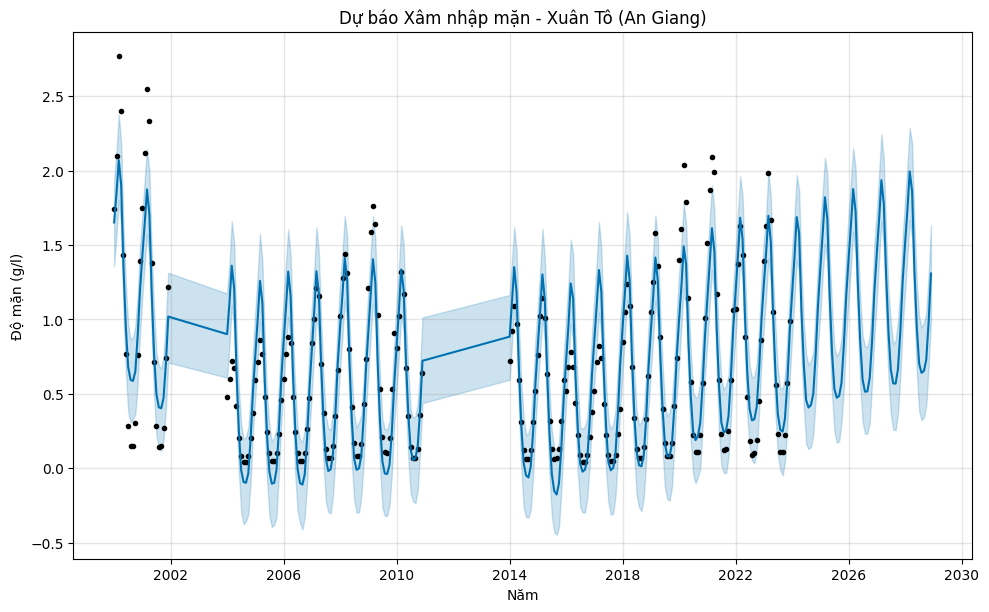


 Đang vẽ biểu đồ mẫu cho trạm: Chủ Chí (Tỉnh Bạc Liêu)


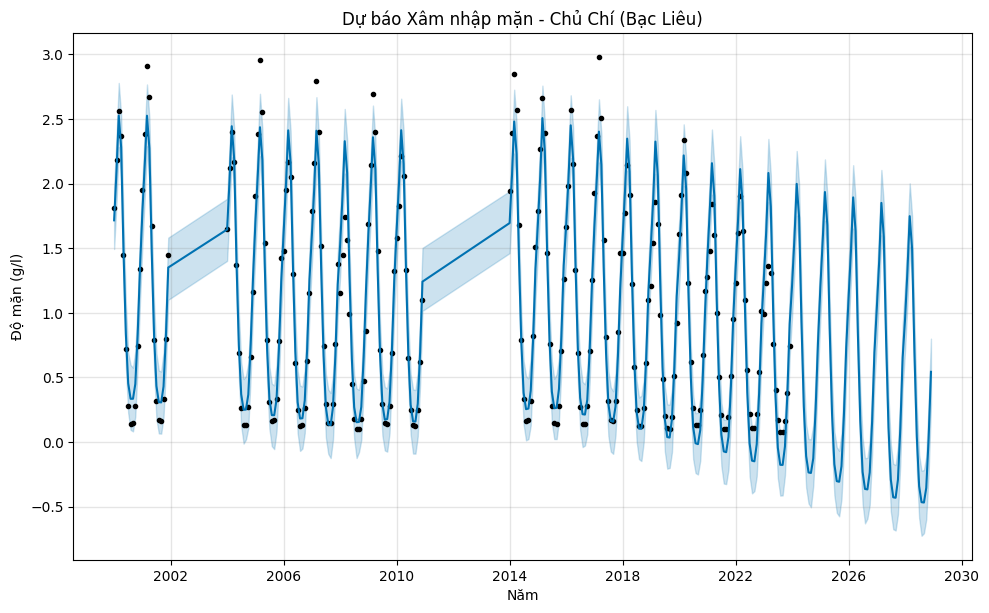


 HOÀN TẤT: 1116 dòng dữ liệu (Dự báo 2026-2028).
 Đã lưu file CSV: Prophet_Forecast_Monthly_2026_2028.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


UPLOAD SUPABASE
 Supabase URL (Nhấn Enter để bỏ qua): 
⏭ Bỏ qua bước Supabase.


In [2]:
!pip install prophet supabase

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import logging
import warnings
from google.colab import files
from prophet import Prophet
from supabase import create_client, Client

logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

ONI_DATA = {
    2000: [-1.7, -1.4, -1.1, -0.8, -0.7, -0.6, -0.6, -0.5, -0.5, -0.6, -0.7, -0.7],
    2001: [-0.7, -0.5, -0.4, -0.3, -0.3, -0.1, -0.1, -0.1, -0.2, -0.3, -0.3, -0.3],
    2002: [-0.1,  0.0,  0.1,  0.2,  0.4,  0.7,  0.8,  0.9,  1.0,  1.2,  1.3,  1.1],
    2003: [ 0.9,  0.6,  0.4,  0.0, -0.3, -0.2,  0.1,  0.2,  0.3,  0.3,  0.4,  0.4],
    2004: [ 0.4,  0.3,  0.2,  0.2,  0.2,  0.3,  0.5,  0.6,  0.7,  0.7,  0.7,  0.7],
    2005: [ 0.6,  0.6,  0.4,  0.4,  0.3,  0.1, -0.1, -0.1, -0.1, -0.3, -0.6, -0.8],
    2006: [-0.9, -0.8, -0.6, -0.4, -0.1,  0.0,  0.1,  0.3,  0.5,  0.8,  0.9,  0.9],
    2007: [ 0.7,  0.2, -0.1, -0.3, -0.4, -0.5, -0.6, -0.8, -1.1, -1.3, -1.5, -1.6],
    2008: [-1.6, -1.5, -1.3, -1.0, -0.8, -0.6, -0.4, -0.2, -0.2, -0.4, -0.6, -0.7],
    2009: [-0.8, -0.8, -0.6, -0.3,  0.0,  0.3,  0.5,  0.6,  0.7,  1.0,  1.4,  1.6],
    2010: [ 1.5,  1.2,  0.8,  0.4, -0.2, -0.7, -1.0, -1.3, -1.6, -1.6, -1.6, -1.5],
    2011: [-1.3, -1.0, -0.8, -0.6, -0.5, -0.4, -0.4, -0.6, -0.8, -1.0, -1.0, -0.9],
    2012: [-0.7, -0.6, -0.5, -0.4, -0.2,  0.1,  0.3,  0.4,  0.4,  0.3,  0.1, -0.1],
    2013: [-0.3, -0.3, -0.2, -0.2, -0.3, -0.3, -0.4, -0.3, -0.2, -0.1, -0.1, -0.2],
    2014: [-0.3, -0.3, -0.1,  0.2,  0.3,  0.2,  0.1,  0.1,  0.3,  0.5,  0.7,  0.8],
    2015: [ 0.7,  0.6,  0.7,  0.8,  1.0,  1.3,  1.6,  1.9,  2.2,  2.5,  2.6,  2.8],
    2016: [ 2.6,  2.3,  1.7,  1.0,  0.5,  0.0, -0.3, -0.5, -0.6, -0.6, -0.6, -0.5],
    2017: [-0.2,  0.0,  0.2,  0.3,  0.4,  0.4,  0.2, -0.1, -0.3, -0.6, -0.8, -0.9],
    2018: [-0.8, -0.7, -0.6, -0.4, -0.1,  0.1,  0.1,  0.3,  0.5,  0.8,  1.0,  0.9],
    2019: [ 0.9,  0.9,  0.8,  0.8,  0.6,  0.5,  0.3,  0.2,  0.2,  0.4,  0.6,  0.7],
    2020: [ 0.6,  0.6,  0.5,  0.3,  0.0, -0.2, -0.4, -0.5, -0.8, -1.1, -1.2, -1.1],
    2021: [-0.9, -0.8, -0.7, -0.5, -0.4, -0.3, -0.3, -0.4, -0.6, -0.8, -0.9, -0.9],
    2022: [-0.8, -0.8, -0.9, -1.0, -0.9, -0.8, -0.8, -0.9, -1.0, -0.9, -0.8, -0.7],
    2023: [-0.5, -0.3,  0.0,  0.3,  0.6,  0.8,  1.1,  1.4,  1.6,  1.8,  2.0,  2.1],
    2024: [ 1.9,  1.6,  1.3,  0.8,  0.5,  0.2,  0.1, -0.1, -0.2, -0.2, -0.3, -0.4],
    2025: [-0.4, -0.2, -0.1,  0.0,  0.0,  0.0, -0.1, -0.3, -0.4, -0.5, -0.6, -0.5],
    # Giả định trung tính (0.0) cho các tháng/năm tương lai chưa có data
    2026: [-0.4, -0.2,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0],
    2027: [ 0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0],
    2028: [ 0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0,  0.0],
}

def get_oni_value(date_obj):
    year = date_obj.year
    month = date_obj.month
    if year in ONI_DATA:
        return ONI_DATA[year][month - 1]
    return 0.0

def calculate_location_factor(lat, lon, tinh):
    base_factor = 0.0
    coastal_high_risk = ['Cà Mau', 'Bạc Liêu', 'Sóc Trăng', 'Kiên Giang', 'Trà Vinh', 'Bến Tre']
    coastal_medium = ['Vĩnh Long', 'Tiền Giang', 'Hậu Giang']
    inland = ['An Giang', 'Đồng Tháp', 'Long An', 'Cần Thơ']

    if any(t in tinh for t in coastal_high_risk):
        base_factor = 1.3
    elif any(t in tinh for t in coastal_medium):
        base_factor = 1.1
    elif any(t in tinh for t in inland):
        base_factor = 0.85
    else:
        base_factor = 1.0

    if lat < 9.5:
        base_factor *= 1.15
    elif lat < 10.0:
        base_factor *= 1.05
    return base_factor

def climate_change_trend(year):
    base_year = 2000
    return 1 + (year - base_year) * 0.005

print(" Vui lòng chọn file MOCK DATA MONTHLY (Có cột Nam, Thang, Tinh...)")
uploaded = files.upload()

if not uploaded:
    print(" Bạn chưa upload file.")
else:
    file_name = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))

    target_col = 'Do_Man'
    if target_col not in df.columns:
        print(f" Không tìm thấy cột '{target_col}' trong file!")
    else:
        print(f" Đã load file. Đang xử lý dự báo THEO THÁNG (2026-2028)...")
        df[target_col] = df[target_col].fillna(0)

        unique_stations = df['Ten_Tram'].unique()
        final_forecasts = []


        STATIONS_TO_PLOT = []

        if not STATIONS_TO_PLOT:
            NUM_PLOTS = 5 # Vẽ 5 trạm đầu tiên làm mẫu
            STATIONS_TO_PLOT = unique_stations[:NUM_PLOTS]

        for station in unique_stations:
            station_df = df[df['Ten_Tram'] == station].copy()

            # 1. CHUẨN BỊ DỮ LIỆU
            prophet_df = pd.DataFrame()

            # Tạo ngày mùng 1 dựa trên Năm và Tháng
            prophet_df['ds'] = pd.to_datetime(
                station_df['Nam'].astype(str) + '-' +
                station_df['Thang'].astype(str) + '-01'
            )
            prophet_df['y'] = station_df[target_col]

            if len(prophet_df) < 5: continue

            tinh = station_df['Tinh'].iloc[0]
            lon = station_df['Lon'].iloc[0]
            lat = station_df['Lat'].iloc[0]
            current_loc_factor = calculate_location_factor(lat, lon, tinh)

            # Thay đổi map hàm ONI theo tháng
            prophet_df['enso'] = prophet_df['ds'].apply(get_oni_value)
            prophet_df['location'] = current_loc_factor
            prophet_df['climate_trend'] = prophet_df['ds'].dt.year.apply(climate_change_trend)

            try:
                # 2. CẤU HÌNH PROPHET
                m = Prophet(
                    growth='linear',
                    yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    changepoint_prior_scale=0.1
                )
                m.add_regressor('enso')
                m.add_regressor('location')
                m.add_regressor('climate_trend')

                m.fit(prophet_df)


                future_end_date = '2028-12-01'

                last_date = prophet_df['ds'].max()
                months_to_predict = (pd.to_datetime(future_end_date).year - last_date.year) * 12 + \
                                    (pd.to_datetime(future_end_date).month - last_date.month)

                if months_to_predict > 0:
                    future = m.make_future_dataframe(periods=months_to_predict, freq='MS')
                else:
                    future = m.make_future_dataframe(periods=12, freq='MS')

                # Thay đổi map hàm ONI theo tháng cho tương lai
                future['enso'] = future['ds'].apply(get_oni_value)
                future['location'] = current_loc_factor
                future['climate_trend'] = future['ds'].dt.year.apply(climate_change_trend)

                forecast = m.predict(future)

                forecast_future = forecast[
                    (forecast['ds'].dt.year >= 2026) &
                    (forecast['ds'].dt.year <= 2028)
                ]

                # Lưu kết quả
                for _, row in forecast_future.iterrows():
                    pred_val = max(0, row['yhat'])

                    final_forecasts.append({
                        'Ngay': row['ds'].strftime('%Y-%m-%d'),
                        'Nam': row['ds'].year,
                        'Thang': row['ds'].month,
                        'Tinh': tinh,
                        'Ten_Tram': station,
                        'Lon': lon,
                        'Lat': lat,
                        'Du_Bao_Man': round(pred_val, 2),
                        'Lower_CI': round(max(0, row['yhat_lower']), 2),
                        'Upper_CI': round(row['yhat_upper'], 2),
                        'He_So_Vi_Tri': round(current_loc_factor, 2)
                    })


                if station in STATIONS_TO_PLOT:
                    print(f"\n Đang vẽ biểu đồ mẫu cho trạm: {station} (Tỉnh {tinh})")
                    fig = m.plot(forecast)
                    # Thêm title và nhãn để dễ phân biệt các trạm
                    plt.title(f"Dự báo Xâm nhập mặn - {station} ({tinh})")
                    plt.xlabel("Năm")
                    plt.ylabel("Độ mặn (g/l)")
                    plt.show()

            except Exception as e:
                print(f" Lỗi trạm {station}: {e}")
                continue

        if final_forecasts:
            df_result = pd.DataFrame(final_forecasts)

            print("\n" + "="*80)
            print(f" HOÀN TẤT: {len(df_result)} dòng dữ liệu (Dự báo 2026-2028).")
            print("="*80)

            output_filename = 'Prophet_Forecast_Monthly_2026_2028.csv'
            cols_export = ['Ngay', 'Nam', 'Thang', 'Tinh', 'Ten_Tram', 'Du_Bao_Man', 'Lon', 'Lat', 'He_So_Vi_Tri']
            df_result[cols_export].to_csv(output_filename, index=False, encoding='utf-8-sig')

            print(f" Đã lưu file CSV: {output_filename}")
            files.download(output_filename)

            # LƯU SUPABASE
            print("\n" + "="*80)
            print("UPLOAD SUPABASE")
            print("="*80)

            sb_url = input(" Supabase URL (Nhấn Enter để bỏ qua): ").strip()
            if sb_url:
                sb_key = input(" Supabase Key (Service Role): ").strip()
                sb_table = input(" Tên bảng (Table): ").strip()

                if sb_key and sb_table:
                    try:
                        supabase: Client = create_client(sb_url, sb_key)

                        df_upload = df_result.rename(columns={
                            'Ngay': 'ngay', 'Nam': 'nam', 'Thang': 'thang',
                            'Tinh': 'tinh', 'Ten_Tram': 'ten_tram',
                            'Lon': 'lon', 'Lat': 'lat', 'Du_Bao_Man': 'du_bao_man',
                            'Lower_CI': 'lower_ci', 'Upper_CI': 'upper_ci',
                            'He_So_Vi_Tri': 'he_so_vi_tri'
                        })

                        records = df_upload.to_dict(orient='records')
                        batch_size = 500
                        total_records = len(records)

                        print(f" Bắt đầu upload {total_records} dòng...")

                        for i in range(0, total_records, batch_size):
                            batch = records[i:i+batch_size]
                            supabase.table(sb_table).upsert(batch, on_conflict='ten_tram,nam,thang').execute()

                            if i % 5000 == 0:
                                 print(f"   -> Đã xử lý {i}/{total_records} dòng...")

                        print(" Upload Supabase thành công!")
                    except Exception as e:
                        print(f" Lỗi Supabase: {e}")
            else:
                print("⏭ Bỏ qua bước Supabase.")
        else:
            print(" Không tạo được dữ liệu dự báo nào.")